# Cross-Country Analysis of COVID-19 Case Trends During 2020

## Research Question

### How did COVID‑19 case trends differ among the United States, United Kingdom, Canada, Germany, and India during the first year of the pandemic?

## Introduction

### During the first year of the pandemic, this project examines how COVID-19 case trends varied among several nations. "How did COVID‑19 case trends differ among the United States, United Kingdom, Canada, Germany, and India during the first year of the pandemic?" is the research question that directs this investigation. Daily COVID-19 case and death counts, population information, and geographic identifiers are all included in the dataset used for this study. The date information in this file is divided into three distinct columns: Date.Day, Date.Month, and Date, in contrast to many COVID datasets.year, necessitating reconstruction into a single datetime variable in order to facilitate time-series analysis.
### Other variables are Data.Cases and Data.Location, Deaths.Data and Country.The population offers the data required to compare case trajectories between nations. Because these variables provide both trend visualization and summary statistics that emphasize variations in COVID-19 evolution across locations, they are suitable for addressing the study issue.

## Data Analysis

### In order to prepare the dataset for cross-country comparison, the analysis uses a number of data-wrangling approaches. In order to properly sort, filter, and exhibit time-series data, the three distinct date components (Date.Day, Date.Month, and Date.Year) were first unified into a single datetime column. missing values in the data.To guarantee precise computations, cases were eliminated. After then, only the five chosen nations that were pertinent to the research question were included in the dataset.
### Summary statistics including the total number of cases in 2020, the average number of new cases per day, and the population size of each nation were calculated using grouping and aggregation procedures. To effectively display these traits, a summary table was made. In order to see variations in daily new cases over time, a multi-country line plot was created using the reconstructed date column. This analytical method shows how COVID-19 trends differed amongst nations using both numerical and visual data.

## Conclusion and Future Directions

### The analysis's findings demonstrate that COVID-19 case trends varied considerably in the US, UK, Canada, Germany, and India in 2020. In contrast to the United States, which saw a consistent growth throughout the year with a significant spike towards the end of 2020, India saw a dramatic increase in cases in the middle of 2020, peaking around September before falling. The UK saw several waves that coincided with recognized times of policy tightening and relaxation, while Canada and Germany maintained comparatively lower and more stable case patterns.
### By showing that each nation followed a unique trajectory influenced by population size, public health actions, and outbreak timing, these data directly address the study issue. To deepen the study, future studies might include more factors like hospitalization statistics, immunization rates, or government policy indices. Additional research could look at socioeconomic variables that affected case trends or investigate regional variations within each nation.

## References

### World Health Organization. (2020). Coronavirus disease (COVID‑19) pandemic. https://www.who.int/emergencies/diseases/novel-coronavirus-2019
### CORGIS Project. (2020). COVID‑19 dataset [Data set]. CORGIS Datasets Project. https://corgis-edu.github.io/corgis/csv/covid/

## Importing Libraries

### The Python libraries needed for data manipulation and visualization are imported into this cell. Matplotlib and Seaborn create the graphics, while Pandas manages data manipulation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Loading the Dataset

### The COVID CSV file is used to load the dataset. For time-series analysis, these values must be combined into a single datetime column because the dataset stores dates in three distinct columns (Date.Day, Date.Month, and Date.Year).

In [2]:
df = pd.read_csv("Downloads/covid.csv")

df['date'] = pd.to_datetime(
    df['Date.Year'].astype(str) + '-' +
    df['Date.Month'].astype(str) + '-' +
    df['Date.Day'].astype(str),
    errors='coerce'
)

df.head()

,Date.Day,Date.Month,Date.Year,Data.Cases,Data.Deaths,Location.Country,Location.Code,Data.Population,Location.Continent,Data.Rate,date
0,31,12,2019,0,0,Afghanistan,AFG,38041757,Asia,0.0,2019-12-31
1,31,12,2019,0,0,Algeria,DZA,43053054,Africa,0.0,2019-12-31
2,31,12,2019,0,0,Armenia,ARM,2957728,Europe,0.0,2019-12-31
3,31,12,2019,0,0,Australia,AUS,25203200,Oceania,0.0,2019-12-31
4,31,12,2019,0,0,Austria,AUT,8858775,Europe,0.0,2019-12-31


## Cleaning the Data

### In this phase, the dataset is filtered to only contain the nations that are pertinent to the research question, the United States, the United Kingdom, Canada, Germany, and India, and rows with missing case values are eliminated.

In [7]:
df = df.dropna(subset=['Data.Cases'])

countries = ["United_States_of_America", "United_Kingdom", "Canada", "Germany", "India"]
df_filtered = df[df['Location.Country'].isin(countries)]

df_filtered.head()

,Date.Day,Date.Month,Date.Year,Data.Cases,Data.Deaths,Location.Country,Location.Code,Data.Population,Location.Continent,Data.Rate,date
11,31,12,2019,0,0,Canada,CAN,37411038,America,0.0,2019-12-31
24,31,12,2019,0,0,Germany,DEU,83019213,Europe,0.0,2019-12-31
27,31,12,2019,0,0,India,IND,1366417756,Asia,0.0,2019-12-31
64,31,12,2019,0,0,United_Kingdom,GBR,66647112,Europe,0.0,2019-12-31
65,31,12,2019,0,0,United_States_of_America,USA,329064917,America,0.0,2019-12-31


## Summary Table

### To compare the population, average daily new cases, and total cases among the chosen nations, a summary table is made.

In [9]:
summary = df_filtered.groupby("Location.Country").agg(
    total_cases_2020 = ("Data.Cases", "sum"),
    avg_daily_new_cases = ("Data.Cases", "mean"),
    population = ("Data.Population", "max")
)

summary

,total_cases_2020,avg_daily_new_cases,population
Location.Country,,,
Canada,247703,796.472669,37411038
Germany,597583,1921.488746,83019213
India,8364086,26980.922581,1366417756
United_Kingdom,1099059,3533.951768,66647112
United_States_of_America,9486486,30503.170418,329064917


## Applying Daily New COVID-19 Cases

### This graphic contrasts the daily number of new COVID-19 cases in the chosen nations throughout the course of 2020. A time-series line graphic is created using the reconstructed date column.

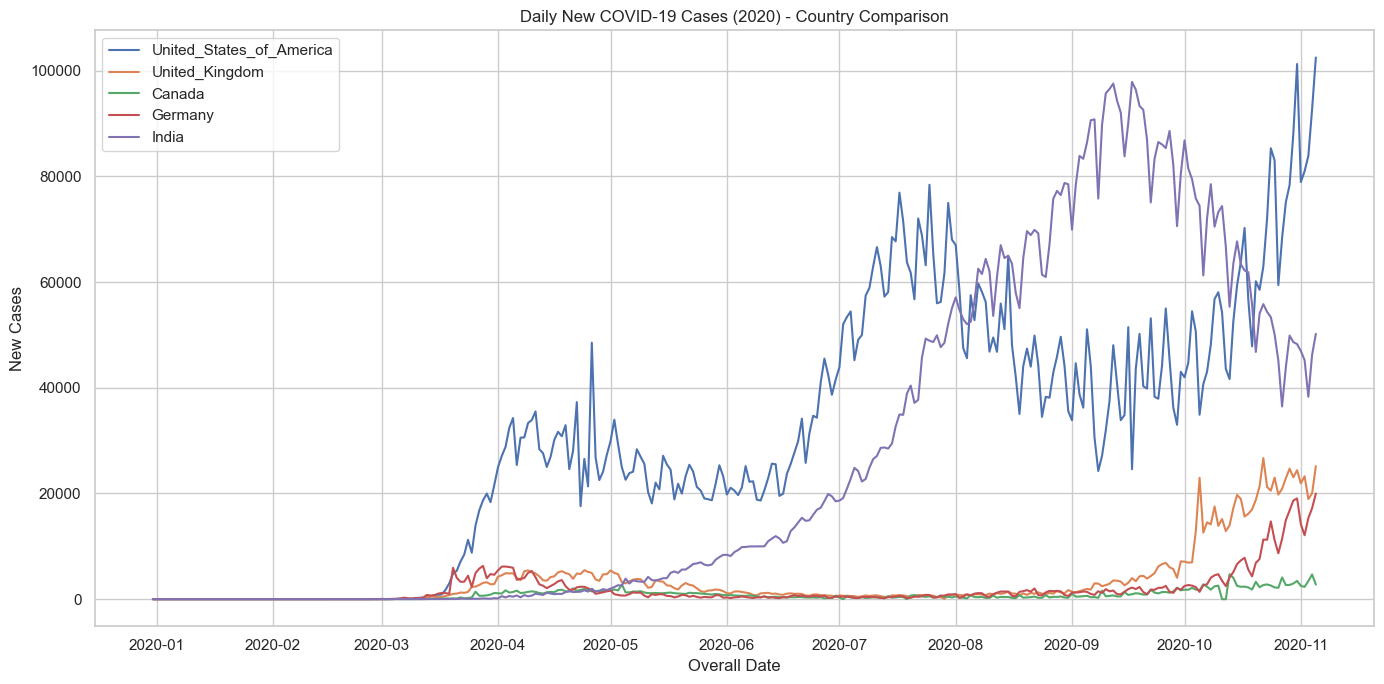

In [8]:
plt.figure(figsize=(14, 7))

for country in countries:
    subset = df_filtered[df_filtered['Location.Country'] == country]
    plt.plot(subset['date'], subset['Data.Cases'], label=country)

plt.title("Daily New COVID-19 Cases (2020) - Country Comparison")
plt.xlabel("Overall Date")
plt.ylabel("New Cases")
plt.legend()
plt.tight_layout()
plt.show()